In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# pip install numpy pandas scikit-learn

In [3]:
dataset = pd.read_csv('TSDcsv.csv')
dataset.head()

,Area,Standard deviation,max deflection,SCI200,SCI300,SCISUB,Temp Road,TSD Index
0,9.884177e+05,182.268992,756.1037,58.7054,110.4476,175.5417,38.5587,100.009353
1,1.305168e+06,138.921647,844.2630,69.3978,105.2301,137.0152,38.3569,99.995496
2,1.028884e+06,183.548690,776.3429,60.5225,94.6360,164.7373,42.5451,99.995271
3,7.310604e+05,214.611613,657.5752,114.0269,177.2713,127.7729,32.4979,99.987278
4,6.741504e+05,214.851477,658.2326,147.7425,218.3060,97.9857,22.6152,99.979331


In [4]:
X = dataset.iloc[:, 0:7]
y = dataset.iloc[:,7]
X0= dataset.iloc[:,0]
X1= dataset.iloc[:,1]
X2= dataset.iloc[:,2]
X3= dataset.iloc[:,3]

In [5]:
X

,Area,Standard deviation,max deflection,SCI200,SCI300,SCISUB,Temp Road
0,9.884177e+05,182.268992,756.1037,58.7054,110.4476,175.5417,38.5587
1,1.305168e+06,138.921647,844.2630,69.3978,105.2301,137.0152,38.3569
2,1.028884e+06,183.548690,776.3429,60.5225,94.6360,164.7373,42.5451
3,7.310604e+05,214.611613,657.5752,114.0269,177.2713,127.7729,32.4979
4,6.741504e+05,214.851477,658.2326,147.7425,218.3060,97.9857,22.6152
...,...,...,...,...,...,...,...
233770,1.954499e+04,10.166246,28.0575,13.5364,17.5459,1.4284,10.8161
233771,1.514299e+04,6.704875,19.7467,4.1035,7.5689,1.4267,21.1939
233772,6.764172e+04,10.589245,52.9212,6.1410,11.1931,5.1773,7.8843
233773,2.430922e+04,11.275609,33.3599,7.7109,13.9353,1.9799,13.0853


In [6]:
y

0         100.009353
1          99.995496
2          99.995271
3          99.987278
4          99.979331
             ...    
233770      0.005832
233771      0.004675
233772      0.003749
233773      0.003715
233774      0.003394
Name: TSD Index, Length: 233775, dtype: float64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
regressor = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

In [9]:

regressor.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,500
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [10]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)

In [11]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.2459818758574925


In [12]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9992248700677054

In [13]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]  # Removed 'auto' to avoid warning
}

In [14]:
grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=1, verbose=2)


In [15]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=  27.9s
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=  27.9s
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=  27.1s
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=  26.8s
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8; total time=  27.7s
[CV] END learning_rate=0.01, max_depth=3, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=1.0; total time=  34.2s
[CV] END lea

KeyboardInterrupt: 

In [ ]:
print("Best Parameters:", grid_search.best_params_)

In [ ]:
# regressor.predict([
#     # [2, 2.72, 78.7, 4.75, 50],
#     [2, 2.72, 71.6, 4.71, 50],
#     [3, 2.72, 86.3, 8.56, 50],
#     [2, 2.55, 71.6, 4.9, 50],
#     [2, 2.55, 78.7, 5.99, 110],
#     [1, 2.72, 71.6, 5.32, 110],
#     [3, 2.55, 71.6, 8.12, 50],
#     [3, 2.55, 78.7, 7.02, 75],
#     [2, 2.72, 86.3, 5.82, 90],
#     [1, 2.55, 78.7, 5.05, 50],
#     [2, 2.55, 71.6, 5.37, 50],
#     [2, 2.55, 86.3, 5.37, 35],
#     [2, 2.72, 71.6, 5.27, 75],
#     [3, 2.55, 86.3, 7.02, 50],
#     [2, 2.72, 86.3, 5.27, 90],
#     [3, 2.72, 86.3, 8.63, 25],
#     [2, 2.72, 71.6, 5.79, 50],
#     [2, 2.55, 86.3, 5.93, 35],
#     [1, 2.72, 71.6, 6.48, 75],
#     [1, 2.55, 86.3, 6.16, 35],
#     [2, 2.55, 71.6, 5.37, 90],
#     [2, 2.55, 71.6, 4.84, 35],
#     [3, 2.72, 71.6, 8.56, 90],
#     [1, 2.55, 71.6, 5.05, 75],
#     [3, 2.55, 78.7, 8.12, 75],
#     [1, 2.72, 86.3, 5.89, 75],
#     [2, 2.72, 86.3, 4.71, 50],
#     [2, 2.55, 86.3, 4.84, 35],
#     [1, 2.55, 86.3, 5.11, 110],
#     [2, 2.55, 78.7, 5.99, 90],
#     [3, 2.72, 86.3, 8.56, 75],
#     [1, 2.55, 71.6, 5.05, 35],
#     [1, 2.72, 86.3, 5.27, 35],
#     [1, 2.72, 86.3, 5.32, 35],
#     [1, 2.55, 71.6, 5.11, 90],
#     [1, 2.55, 71.6, 6.16, 75],
#     [2, 2.55, 86.3, 4.9, 110],
#     [2, 2.72, 71.6, 5.79, 90],
#     [1, 2.55, 78.7, 5.58, 75],
#     [3, 2.55, 86.3, 7.02, 25],
#     [3, 2.55, 86.3, 7.06, 90],
#     [1, 2.55, 78.7, 6.23, 35],
#     [1, 2.72, 78.7, 5.89, 35],
#     [1, 2.55, 71.6, 6.16, 50],
#     [3, 2.72, 78.7, 8.63, 75],
#     [2, 2.55, 71.6, 5.99, 75],
#     [3, 2.55, 71.6, 9.56, 35],
#     [1, 2.55, 71.6, 6.23, 50],
#     [2, 2.55, 86.3, 5.93, 110],
#     [2, 2.55, 78.7, 5.37, 50],
#     [3, 2.72, 71.6, 8.63, 90],
#     [3, 2.55, 86.3, 9.54, 35],
#     [1, 2.55, 86.3, 5.58, 110],
#     [1, 2.72, 71.6, 5.27, 90],
#     [3, 2.72, 86.3, 7.73, 75],
#     [3, 2.55, 71.6, 8.12, 25],
#     [3, 2.72, 78.7, 8.63, 25],
#     [1, 2.72, 71.6, 6.48, 35],
#     [1, 2.55, 86.3, 5.58, 35],
#     [3, 2.72, 78.7, 8.63, 90],
#     [2, 2.55, 86.3, 5.37, 90],
#     [3, 2.72, 86.3, 7.39, 35],
#     [1, 2.55, 78.7, 6.23, 75],
#     [3, 2.72, 86.3, 8.56, 90],
#     [1, 2.72, 71.6, 5.27, 75],
#     [1, 2.72, 78.7, 5.27, 50],
#     [3, 2.72, 78.7, 8.63, 50],
#     [1, 2.55, 78.7, 5.58, 50],
#     [3, 2.55, 86.3, 8.12, 25],
#     [3, 2.55, 71.6, 7.06, 90],
#     [1, 2.55, 78.7, 6.23, 110],
#     [1, 2.55, 86.3, 5.58, 90],
#     [3, 2.55, 78.7, 9.56, 50],
#     [1, 2.72, 86.3, 5.89, 50],
#     [3, 2.72, 86.3, 8.63, 90],
#     [1, 2.72, 86.3, 6.5, 110],
#     [1, 2.55, 86.3, 5.05, 90],
#     [2, 2.72, 86.3, 4.71, 35],
#     [3, 2.55, 71.6, 9.56, 50],
#     [2, 2.72, 71.6, 5.82, 110],
#     [2, 2.55, 71.6, 5.99, 90],
#     [2, 2.55, 71.6, 4.84, 50],
#     [1, 2.72, 71.6, 5.32, 75],
#     [1, 2.72, 78.7, 6.5, 75],
#     [1, 2.55, 71.6, 5.05, 90],
#     [3, 2.55, 86.3, 8.12, 35],
#     [2, 2.55, 78.7, 4.84, 110],
#     [2, 2.72, 78.7, 5.27, 50],
#     [1, 2.55, 86.3, 5.11, 90],
#     [3, 2.72, 86.3, 7.78, 75]
# ]
# )

c:\Users\hp\Desktop\TSD ML\TSD ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 5 features, but GradientBoostingRegressor is expecting 7 features as input.

In [16]:
import pickle
with open('TSDgbr.pkl', 'wb') as f:
    pickle.dump(regressor, f)

In [17]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 9.3 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.4 MB/s eta 0:00:00
Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl (13.1 MB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: c:\Users\hp\Desktop\website\BC DBM SMA\.venv\Scripts\python.exe -m pip install --upgrade pip


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix =dataset.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations")
plt.show()


ModuleNotFoundError: No module named 'seaborn'

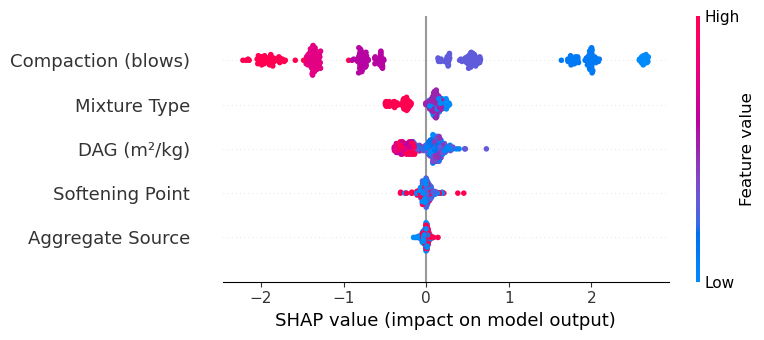

In [ ]:

import shap

# Create SHAP explainer and compute values
explainer = shap.Explainer(regressor, X_train)
shap_values = explainer(X_train)

# Plot SHAP summary
shap.summary_plot(shap_values, X_train)


